## Librerias

In [202]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import random


from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

## seccion 1

### Data sets

In [203]:
df = pd.read_csv("../data/movies_2026.csv", encoding="latin1")
print("Dimensiones del dataset:", df.shape)
df.head()

variables_rules = ['genres','budget','revenue','popularity','voteAvg','releaseYear']
df_rules = df[variables_rules].copy()

Dimensiones del dataset: (19883, 28)


In [204]:
df.columns

Index(['id', 'budget', 'genres', 'homePage', 'productionCompany',
       'productionCompanyCountry', 'productionCountry', 'revenue', 'runtime',
       'video', 'director', 'actors', 'actorsPopularity', 'actorsCharacter',
       'originalTitle', 'title', 'originalLanguage', 'popularity',
       'releaseDate', 'voteAvg', 'voteCount', 'genresAmount',
       'productionCoAmount', 'productionCountriesAmount', 'actorsAmount',
       'castWomenAmount', 'castMenAmount', 'releaseYear'],
      dtype='object')

### variables numericas relevantes

In [205]:
variables_cluster = [
    'popularity',
    'budget',
    'revenue',
    'runtime',
    'voteAvg',
    'voteCount',
    'actorsPopularity',
    'actorsAmount',
    'genresAmount',
    'productionCountriesAmount',
    'castWomenAmount',
    'castMenAmount',
    'releaseYear'
]

df_cluster = df[variables_cluster].copy()

In [206]:
df_cluster.dtypes

popularity                   float64
budget                       float64
revenue                      float64
runtime                        int64
voteAvg                      float64
voteCount                      int64
actorsPopularity              object
actorsAmount                   int64
genresAmount                   int64
productionCountriesAmount      int64
castWomenAmount              float64
castMenAmount                float64
releaseYear                  float64
dtype: object

In [207]:
df_cluster = df_cluster.apply(pd.to_numeric, errors='coerce')
df_cluster = df_cluster.dropna()

print("Dimensiones después de limpiar:", df_cluster.shape)
df_cluster.dtypes

Dimensiones después de limpiar: (1075, 13)


popularity                   float64
budget                       float64
revenue                      float64
runtime                        int64
voteAvg                      float64
voteCount                      int64
actorsPopularity             float64
actorsAmount                   int64
genresAmount                   int64
productionCountriesAmount      int64
castWomenAmount              float64
castMenAmount                float64
releaseYear                  float64
dtype: object

In [208]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

X_scaled[:5]

array([[-0.15839188, -0.04835959, -0.03054557,  0.39928389, -0.4522403 ,
        -0.15152811, -0.23779386,  0.0749181 , -1.32713252,  0.63677232,
        -0.41509153, -0.07265112,  0.49775914],
       [-0.14718048, -0.04835959, -0.03054557, -0.64835717, -0.4522403 ,
        -0.15152811, -0.21757567,  0.0749181 ,  2.29079002,  0.63677232,
        -0.41509153, -0.07265112,  0.49775914],
       [-0.15913614, -0.03677201, -0.03054557, -0.64835717, -0.4522403 ,
        -0.15152811, -0.22971788,  0.0749181 , -0.12115834,  0.63677232,
        -0.41509153, -0.07265112,  0.49775914],
       [-0.13954785, -0.04835959, -0.03054557, -0.5086717 , -0.4522403 ,
        -0.15152811, -0.23779386,  0.0749181 , -0.12115834,  0.63677232,
        -0.41509153, -0.07265112,  0.49775914],
       [-0.1625249 , -0.04835959, -0.03054557,  1.3538013 , -0.4522403 ,
        -0.15152811,  0.11788815,  0.0749181 , -0.12115834,  0.63677232,
        -0.41509153, -0.07263056,  0.49775914]])

### Analisis de la tendencia al agrupamiento

In [209]:
def hopkins(X):
    d = X.shape[1]
    n = len(X)
    m = int(0.1 * n)

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    ujd = []
    wjd = []

    for _ in range(m):
        rand_point = np.random.uniform(np.min(X, axis=0), np.max(X, axis=0), d)
        u_dist, _ = nbrs.kneighbors([rand_point], 2)
        ujd.append(u_dist[0][1])

        rand_index = np.random.randint(0, n)
        w_dist, _ = nbrs.kneighbors([X[rand_index]], 2)
        wjd.append(w_dist[0][1])

    H = sum(ujd) / (sum(ujd) + sum(wjd))
    return H

In [210]:
hopkins_value = hopkins(X_scaled)
print("Hopkins statistic:", hopkins_value)

Hopkins statistic: 0.9798433386802542


### Número Óptimo de Clusters (metodo codo)

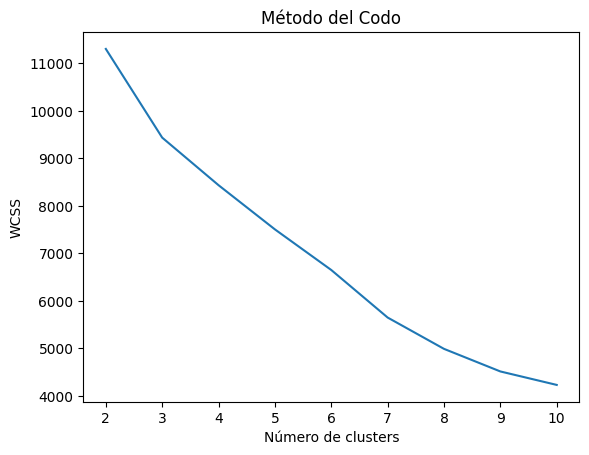

In [211]:
wcss = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(2, 11), wcss)
plt.xlabel("Número de clusters")
plt.ylabel("WCSS")
plt.title("Método del Codo")
plt.show()

### K-Means (k=7)

In [212]:
k_optimo = 7

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

df_cluster['cluster_kmeans'] = clusters_kmeans

df_cluster.head()

,popularity,budget,revenue,runtime,voteAvg,voteCount,actorsPopularity,actorsAmount,genresAmount,productionCountriesAmount,castWomenAmount,castMenAmount,releaseYear,cluster_kmeans
13,0.0404,0.0,0.0,45,0.0,0,0.0071,1,0,1,0.0,0.0,2026.0,2
18,0.1112,0.0,0.0,0,0.0,0,0.0429,1,3,1,0.0,0.0,2026.0,2
23,0.0357,300.0,0.0,0,0.0,0,0.0214,1,1,1,0.0,0.0,2026.0,2
26,0.1594,0.0,0.0,6,0.0,0,0.0071,1,1,1,0.0,0.0,2026.0,2
36,0.0143,0.0,0.0,86,0.0,0,0.6369,1,1,1,0.0,1.0,2026.0,2


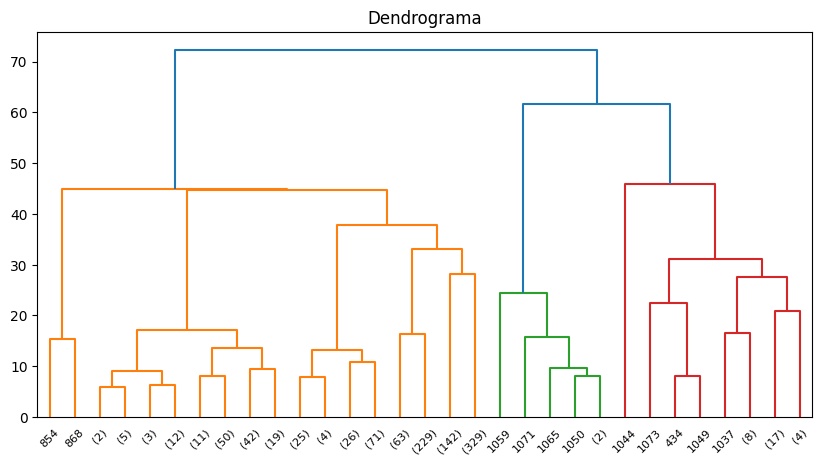

In [213]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Dendrograma")
plt.show()

clusters_hier = fcluster(Z, k_optimo, criterion='maxclust')
df_cluster['cluster_hier'] = clusters_hier

### Calidad del Agrupamiento

In [214]:
sil_kmeans = silhouette_score(X_scaled, clusters_kmeans)
sil_hier = silhouette_score(X_scaled, clusters_hier)

print("Silhouette KMeans:", sil_kmeans)
print("Silhouette Jerárquico:", sil_hier)

Silhouette KMeans: 0.27133049343822824
Silhouette Jerárquico: 0.35910519639436844


### interpretacion (clusters)

#### tamaño 

In [215]:
df_cluster['cluster_hier'].value_counts().sort_index()

cluster_hier
1      2
2    144
3    126
4    763
5      6
6     33
7      1
Name: count, dtype: int64

##### medias

In [216]:
df_cluster.groupby('cluster_hier').mean()

,popularity,budget,revenue,runtime,voteAvg,voteCount,actorsPopularity,actorsAmount,genresAmount,productionCountriesAmount,castWomenAmount,castMenAmount,releaseYear,cluster_kmeans
cluster_hier,,,,,,,,,,,,,,
1,0.125550,572277.000000,0.000000e+00,84.000000,0.000000,0.000000,0.595750,1.0,1.500000,3.000000,0.000000,0.500000,2025.000000,5.000000
2,0.172450,261.784722,2.083333e-01,34.513889,1.314347,0.298611,0.524724,1.0,1.097222,0.583333,1.000000,0.000000,2025.173611,6.000000
3,0.291223,107.015873,1.587302e-01,28.706349,7.783135,2.420635,0.490006,1.0,1.253968,0.603175,0.000000,0.539683,2025.230159,1.206349
4,0.088755,195.984273,2.257929e+01,23.465269,0.032372,0.027523,0.162943,1.0,1.053735,0.583224,0.000000,0.342071,2025.290957,1.072084
5,37.168167,100.000000,0.000000e+00,163.000000,8.066667,24.833333,3.509667,0.0,1.000000,1.000000,0.666667,633082.500000,2015.666667,3.000000
6,22.680585,1.515152,0.000000e+00,67.272727,6.991333,86.000000,5.100742,1.0,1.606061,1.242424,0.272727,0.484848,2016.818182,1.242424
7,17.727000,0.000000,1.666108e+07,81.000000,6.900000,103.000000,8.069000,1.0,1.000000,1.000000,1.000000,0.000000,2015.000000,4.000000


In [217]:
#budget
df_cluster.groupby('cluster_hier')['budget'].mean().sort_values()


cluster_hier
7         0.000000
6         1.515152
5       100.000000
3       107.015873
4       195.984273
2       261.784722
1    572277.000000
Name: budget, dtype: float64

In [218]:
#revenue
df_cluster.groupby('cluster_hier')['revenue'].mean().sort_values()


cluster_hier
1    0.000000e+00
5    0.000000e+00
6    0.000000e+00
3    1.587302e-01
2    2.083333e-01
4    2.257929e+01
7    1.666108e+07
Name: revenue, dtype: float64

In [219]:
#popularity
df_cluster.groupby('cluster_hier')['popularity'].mean().sort_values()

cluster_hier
4     0.088755
1     0.125550
2     0.172450
3     0.291223
7    17.727000
6    22.680585
5    37.168167
Name: popularity, dtype: float64

### Reglas de asociacion 

In [220]:
def dividir_en_3_grupos(columna, etiquetas) :
    columna = pd.to_numeric(columna, errors ='coerce')
    
    limite1= columna.quantile(0.33  )
    limite2= columna.quantile(0.66 )

    if limite1 ==  limite2:
        mediana = columna.quantile( 0.5)
        
        if mediana  == columna.min() or  mediana == columna.max():
            return pd.Series([etiquetas[0]] *  len(columna), index=columna.index)
        
        return pd.cut(  columna, bins=[-np.inf, mediana, np.inf],  labels=[etiquetas[0], etiquetas[-1]] )

    return pd.cut( columna, bins=[-np.inf, limite1, limite2, np.inf], labels=etiquetas )

In [238]:
columnas_numericas = ['budget','revenue','popularity','voteAvg','releaseYear']
# limpiar 
for nombre_columna in columnas_numericas:
    df_rules[nombre_columna ] = (
        df_rules[nombre_columna ]
        .astype(str)
        .str.replace(',' , '', regex= False)
        .replace('nan', np.nan )
    )
    
    df_rules[nombre_columna ] =  pd.to_numeric(df_rules[nombre_columna], errors='coerce')

df_rules = df_rules.dropna()
# crear las cates 
df_rules['budget_nivel' ] = dividir_en_3_grupos(df_rules['budget'] , ['bajo','medio','alto'])
df_rules['revenue_nivel' ] = dividir_en_3_grupos(df_rules['revenue'] , ['bajo','medio','alto'] )
df_rules['popularidad_nivel' ]= dividir_en_3_grupos(df_rules[ 'popularity'], ['bajo','medio','alto'])
df_rules['voto_nivel' ] = dividir_en_3_grupos(df_rules['voteAvg'] , ['bajo','medio','alto' ])
df_rules['anio_nivel' ]= dividir_en_3_grupos(df_rules['releaseYear'] , ['antiguo','medio','reciente' ] )


print(df_rules[['budget','budget_nivel']].head())
print( )
print(df_rules['budget_nivel'].value_counts(dropna =False))

   budget budget_nivel
0     0.0         bajo
1     0.0         bajo
2     0.0         bajo
3     0.0         bajo
4     0.0         bajo

budget_nivel
bajo     11439
alto      6092
medio      386
Name: count, dtype: int64


In [239]:
def separar_generos(valor):
    if pd.isna(valor):
        return [ ]
    texto = str(valor)
    if "|" in texto :
        return [ g.strip() for  g  in texto.split("|") ]
    elif "," in texto:
        return [ g.strip() for g in texto.split(",") ]
    else:
        return [ texto.strip() ]
    


df_rules['lista_generos'] = df_rules['genres'].apply(separar_generos)


In [240]:
df_rules['cosas_pelicula' ] = df_rules.apply(lambda fila: (
    [f"genero={g}"  for g in fila[ 'lista_generos']] +
    [f"budget={fila['budget_nivel' ] }" ,
     f"revenue={fila['revenue_nivel']}" ,
     f"popularidad={fila['popularidad_nivel']}",
     f"voto={fila['voto_nivel']}" ,
        f"anio={fila['anio_nivel'] }"]
), axis=1)

lista_transacciones = df_rules['cosas_pelicula' ].tolist()


encoder = TransactionEncoder()

df_binario = pd.DataFrame(
    encoder.fit(lista_transacciones).transform(lista_transacciones),
    columns=encoder.columns_
)

df_binario.head( )

,anio=antiguo,anio=medio,anio=reciente,budget=alto,budget=bajo,budget=medio,genero=Action,genero=Adventure,genero=Animation,genero=Comedy,...,genero=Thriller,genero=War,genero=Western,popularidad=alto,popularidad=bajo,popularidad=medio,revenue=bajo,voto=alto,voto=bajo,voto=medio
0,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
1,False,False,True,False,True,False,False,False,True,False,...,False,False,False,False,True,False,True,False,True,False
2,False,False,True,False,True,False,False,False,True,False,...,False,False,False,False,True,False,True,False,True,False
3,False,False,True,False,True,False,False,False,False,False,...,True,False,False,False,True,False,True,False,True,False
4,False,False,True,False,True,False,False,False,True,False,...,False,False,False,False,True,False,True,False,True,False


In [241]:
itemsets_05 = apriori( df_binario, min_support=0.05, use_colnames= True)

reglas_05 = association_rules(
    itemsets_05,
    metric="confidence" ,
    min_threshold=0.6 )

reglas_05.sort_values(by="lift", ascending= False).head(12 )

c:\Users\belen\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
800,"(voto=bajo, genero=Documentary)","(anio=medio, popularidad=bajo, budget=bajo, re...",0.103700,0.203940,0.064073,0.617869,3.029653,1.0,0.042925,2.083210,0.747439,0.263061,0.519971,0.466022
797,"(voto=bajo, revenue=bajo, genero=Documentary)","(anio=medio, popularidad=bajo, budget=bajo)",0.103700,0.203940,0.064073,0.617869,3.029653,1.0,0.042925,2.083210,0.747439,0.263061,0.519971,0.466022
669,"(voto=bajo, genero=Documentary)","(anio=medio, popularidad=bajo, budget=bajo)",0.103700,0.203940,0.064073,0.617869,3.029653,1.0,0.042925,2.083210,0.747439,0.263061,0.519971,0.466022
665,"(anio=medio, voto=bajo, genero=Documentary)","(popularidad=bajo, budget=bajo)",0.079143,0.272534,0.064073,0.809591,2.970600,1.0,0.042504,3.820541,0.720381,0.222783,0.738257,0.522346
787,"(anio=medio, voto=bajo, revenue=bajo, genero=D...","(popularidad=bajo, budget=bajo)",0.079143,0.272534,0.064073,0.809591,2.970600,1.0,0.042504,3.820541,0.720381,0.222783,0.738257,0.522346
793,"(anio=medio, voto=bajo, genero=Documentary)","(popularidad=bajo, budget=bajo, revenue=bajo)",0.079143,0.272534,0.064073,0.809591,2.970600,1.0,0.042504,3.820541,0.720381,0.222783,0.738257,0.522346
762,"(voto=bajo, genero=Documentary)","(popularidad=bajo, budget=bajo, revenue=bajo)",0.103700,0.272534,0.083105,0.801399,2.940543,1.0,0.054843,3.662957,0.736279,0.283511,0.726996,0.553167
759,"(voto=bajo, revenue=bajo, genero=Documentary)","(popularidad=bajo, budget=bajo)",0.103700,0.272534,0.083105,0.801399,2.940543,1.0,0.054843,3.662957,0.736279,0.283511,0.726996,0.553167
555,"(voto=bajo, genero=Documentary)","(popularidad=bajo, budget=bajo)",0.103700,0.272534,0.083105,0.801399,2.940543,1.0,0.054843,3.662957,0.736279,0.283511,0.726996,0.553167
668,"(popularidad=bajo, genero=Documentary)","(anio=medio, voto=bajo, budget=bajo)",0.099347,0.222582,0.064073,0.644944,2.897557,1.0,0.041960,2.189564,0.727119,0.248485,0.543288,0.466404


In [242]:
itemsets_05 = apriori(df_binario, min_support=0.05, use_colnames=True)
reglas_05= association_rules(itemsets_05, metric="confidence", min_threshold= 0.6)

itemsets_02 = apriori(df_binario, min_support=0.02, use_colnames=True)
reglas_02= association_rules(itemsets_02, metric="confidence", min_threshold= 0.6)

itemsets_01 = apriori(df_binario, min_support=0.01, use_colnames=True)
reglas_01= association_rules(itemsets_01, metric="confidence", min_threshold=0.6)

print( len( reglas_05) , len(reglas_02), len(reglas_01 ))

c:\Users\belen\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
c:\Users\belen\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


816 2656 6701


c:\Users\belen\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


In [243]:
regla_confianza50 = association_rules(itemsets_02, metric="confidence", min_threshold=0.5)
regla_confianza60 = association_rules(itemsets_02, metric="confidence", min_threshold=0.6)
regla_confianza70 = association_rules(itemsets_02, metric="confidence", min_threshold=0.7)

print(len(regla_confianza50 ), len(regla_confianza60 ) , len(regla_confianza70 ))

3809 2656 1818


c:\Users\belen\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
c:\Users\belen\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
c:\Users\belen\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


In [244]:
frecuencia_items= df_binario.mean( ).sort_values(ascending=False)

items_demasiado_comunes= frecuencia_items[frecuencia_items > 0.70 ].index

df_binario_filtrado= df_binario.drop(columns=items_demasiado_comunes )

itemsets_filtrado= apriori(df_binario_filtrado, min_support=0.02, use_colnames= True)
reglas_filtradas= association_rules(itemsets_filtrado, metric="confidence" , min_threshold = 0.6 ) 

print("Reglas antes:", len(reglas_02 ))
print("Reglas después:", len(reglas_filtradas ))

reglas_filtradas.sort_values("lift", ascending=False).head(12 ) 

Reglas antes: 2656
Reglas después: 631


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
252,"(genero=Comedy, genero=Animation)",(genero=Family),0.034939,0.097170,0.024781,0.709265,7.299198,1.0,0.021386,3.105337,0.894242,0.230889,0.677974,0.482146
243,"(genero=Adventure, genero=Animation)",(genero=Family),0.036055,0.097170,0.023776,0.659443,6.786465,1.0,0.020273,2.651036,0.884540,0.217236,0.622789,0.452065
581,"(voto=alto, popularidad=alto, genero=Family)",(genero=Animation),0.034158,0.110510,0.024613,0.720588,6.520596,1.0,0.020839,3.183439,0.876582,0.205021,0.685874,0.471658
257,"(voto=alto, genero=Family)",(genero=Animation),0.047664,0.110510,0.031032,0.651054,5.891380,1.0,0.025765,2.549077,0.871815,0.244074,0.607701,0.465931
256,"(popularidad=alto, genero=Family)",(genero=Animation),0.054473,0.110510,0.034939,0.641393,5.803963,1.0,0.028919,2.480408,0.875389,0.268670,0.596840,0.478778
394,"(anio=antiguo, popularidad=alto, genero=Family)",(genero=Animation),0.035944,0.110510,0.022827,0.635093,5.746952,1.0,0.018855,2.437582,0.856791,0.184650,0.589757,0.420829
244,"(genero=Adventure, genero=Family)",(genero=Animation),0.038678,0.110510,0.023776,0.614719,5.562583,1.0,0.019502,2.308677,0.853229,0.189586,0.566852,0.414935
554,"(voto=bajo, genero=Animation)","(popularidad=bajo, budget=bajo)",0.025507,0.272534,0.021321,0.835886,3.067084,1.0,0.014369,4.432690,0.691598,0.077047,0.774403,0.457058
619,"(voto=bajo, genero=Documentary)","(anio=medio, popularidad=bajo, budget=bajo)",0.103700,0.203940,0.064073,0.617869,3.029653,1.0,0.042925,2.083210,0.747439,0.263061,0.519971,0.466022
615,"(anio=medio, voto=bajo, genero=Documentary)","(popularidad=bajo, budget=bajo)",0.079143,0.272534,0.064073,0.809591,2.970600,1.0,0.042504,3.820541,0.720381,0.222783,0.738257,0.522346


In [245]:
print("Top 10 items más frecuentes (antes de filtrar):")
print((frecuencia_items.head(10) * 100).round(2).astype(str) + "%")

Top 10 items más frecuentes (antes de filtrar):
revenue=bajo         100.0%
budget=bajo          63.84%
anio=medio           53.58%
genero=Drama         36.62%
voto=bajo            36.35%
anio=antiguo         34.63%
budget=alto           34.0%
popularidad=alto      34.0%
popularidad=bajo      33.0%
popularidad=medio     33.0%
dtype: object


In [246]:
items_demasiado_comunes = frecuencia_items[frecuencia_items > 0.70].index
print("\nItems eliminados (frecuencia > 70%):")
print(list(items_demasiado_comunes))


Items eliminados (frecuencia > 70%):
['revenue=bajo']


In [247]:
print("Lift promedio:", reglas_02['lift'].mean())
print("Lift máximo:", reglas_02['lift'].max())
print("Confidence promedio:", reglas_02['confidence'].mean())
print("Support promedio:", reglas_02['support'].mean())

Lift promedio: 1.6728422531818794
Lift máximo: 7.299198250060099
Confidence promedio: 0.8009904877229512
Support promedio: 0.05371774534651414


In [248]:
print("Antes - Lift promedio:", reglas_02['lift'].mean())
print("Después - Lift promedio:", reglas_filtradas['lift'].mean())

Antes - Lift promedio: 1.6728422531818794
Después - Lift promedio: 1.9440406890919557


In [249]:
print("Lift promedio:", reglas_filtradas['lift'].mean())
print("Lift máximo:", reglas_filtradas['lift'].max())
print("Confidence promedio:", reglas_filtradas['confidence'].mean())
print("Support promedio:", reglas_filtradas['support'].mean())

Lift promedio: 1.9440406890919557
Lift máximo: 7.299198250060099
Confidence promedio: 0.7209679299821616
Support promedio: 0.05284731222779594


In [250]:
reglas_filtradas \
    .sort_values("lift", ascending=False) \
    [["antecedents", "consequents", "support", "confidence", "lift"]] \
    .head(12)

,antecedents,consequents,support,confidence,lift
252,"(genero=Comedy, genero=Animation)",(genero=Family),0.024781,0.709265,7.299198
243,"(genero=Adventure, genero=Animation)",(genero=Family),0.023776,0.659443,6.786465
581,"(voto=alto, popularidad=alto, genero=Family)",(genero=Animation),0.024613,0.720588,6.520596
257,"(voto=alto, genero=Family)",(genero=Animation),0.031032,0.651054,5.891380
256,"(popularidad=alto, genero=Family)",(genero=Animation),0.034939,0.641393,5.803963
394,"(anio=antiguo, popularidad=alto, genero=Family)",(genero=Animation),0.022827,0.635093,5.746952
244,"(genero=Adventure, genero=Family)",(genero=Animation),0.023776,0.614719,5.562583
554,"(voto=bajo, genero=Animation)","(popularidad=bajo, budget=bajo)",0.021321,0.835886,3.067084
619,"(voto=bajo, genero=Documentary)","(anio=medio, popularidad=bajo, budget=bajo)",0.064073,0.617869,3.029653
615,"(anio=medio, voto=bajo, genero=Documentary)","(popularidad=bajo, budget=bajo)",0.064073,0.809591,2.970600


# 3. Análisis de Componentes Principales (PCA)

In [16]:
print(df.shape)

(19883, 28)


In [17]:
variables_pca = [
    'popularity',
    'budget',
    'revenue',
    'runtime',
    'voteAvg',
    'actorsAmount',
    'genresAmount',
    'productionCountriesAmount',
    'castWomenAmount',
    'releaseYear'
]

df_pca = df[variables_pca].copy()

df_pca = df_pca[(df_pca['budget'] > 0) & (df_pca['revenue'] > 0)]

print("Dimensiones después del filtro:", df_pca.shape)

Dimensiones después del filtro: (4502, 10)


In [18]:
(df_pca['budget'] == 0).mean()

np.float64(0.0)

In [19]:
(df_pca['revenue'] == 0).mean()

np.float64(0.0)

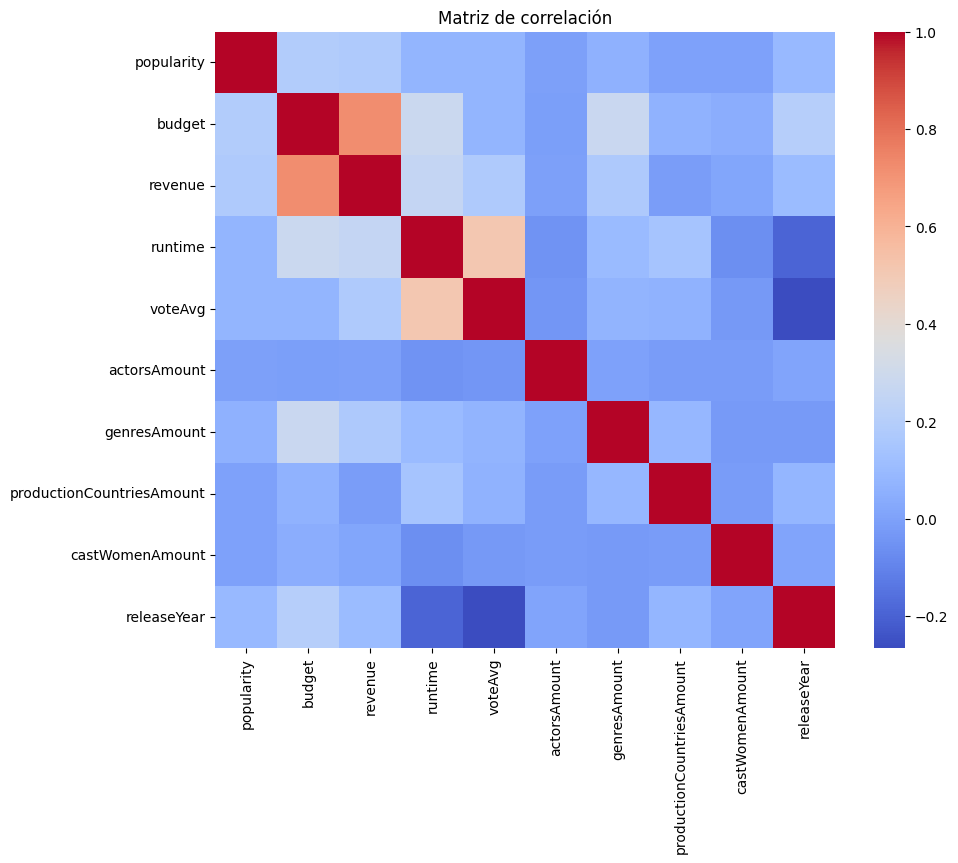

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_pca.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Matriz de correlación")
plt.show()

In [21]:
df_pca = df_pca.dropna()
print("Dimensiones después de eliminar NaN:", df_pca.shape)

Dimensiones después de eliminar NaN: (4500, 10)


In [22]:
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_pca)

chi_square_value, p_value = calculate_bartlett_sphericity(df_scaled)

print("Bartlett p-value:", p_value)

Bartlett p-value: 0.0


In [23]:
df_pca.var()

popularity                   8.767833e+04
budget                       2.150780e+15
revenue                      4.218688e+16
runtime                      6.607918e+02
voteAvg                      1.526152e+00
actorsAmount                 6.772168e+02
genresAmount                 1.148750e+00
productionCountriesAmount    1.046404e+00
castWomenAmount              1.155318e+08
releaseYear                  2.148714e+02
dtype: float64

In [24]:
df_pca.isnull().sum()

popularity                   0
budget                       0
revenue                      0
runtime                      0
voteAvg                      0
actorsAmount                 0
genresAmount                 0
productionCountriesAmount    0
castWomenAmount              0
releaseYear                  0
dtype: int64

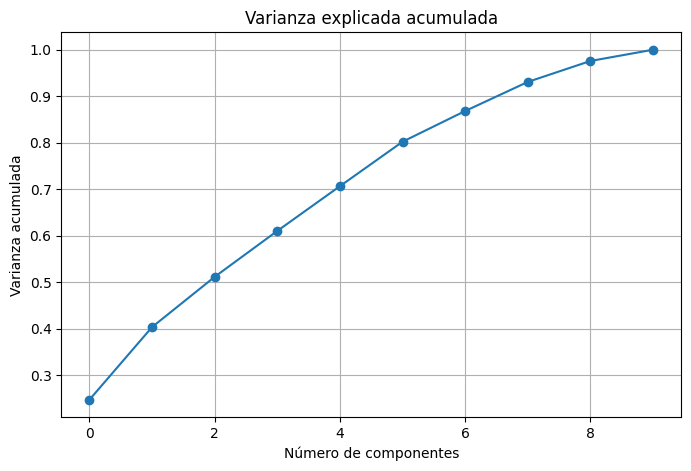

In [25]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(df_scaled)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Varianza explicada acumulada')
plt.grid()
plt.show()

In [26]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(df_pca.columns))],
    index=df_pca.columns
)

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
popularity,0.177,0.189,-0.001,-0.218,0.194,0.870,0.297,-0.052,0.015,-0.009
budget,0.492,0.359,-0.041,0.039,0.021,-0.132,-0.146,-0.221,0.157,0.716
revenue,0.490,0.271,-0.171,-0.036,0.010,-0.101,-0.275,-0.371,-0.191,-0.628
runtime,0.423,-0.388,0.083,0.011,-0.155,0.060,-0.078,0.213,0.740,-0.189
voteAvg,0.312,-0.497,0.019,0.045,0.022,0.233,-0.452,0.273,-0.535,0.184
actorsAmount,0.392,-0.098,-0.222,-0.091,-0.324,-0.231,0.700,0.220,-0.285,0.012
genresAmount,0.218,0.113,0.362,0.200,0.746,-0.228,0.185,0.336,-0.040,-0.110
productionCountriesAmount,0.085,-0.028,0.792,0.294,-0.363,0.080,0.139,-0.317,-0.141,-0.028
castWomenAmount,-0.017,0.113,-0.350,0.895,-0.077,0.209,0.048,0.093,0.030,-0.040
releaseYear,-0.010,0.574,0.178,-0.105,-0.372,0.055,-0.240,0.649,-0.029,-0.086
